## 1. Import and setup

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import colorsys
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

from utils.analysis_functions import (
    plot_single_time_gap,
    plot_triple_time_gap,
    build_summary_table
)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.dpi'] = 100

In [46]:
results_to_use = 'paper' # Switch to 'experiment' for analysis of script-generated results

In [47]:
# r_max to identify radii regimes
small_r = [0.25, 0.3, 0.375]
med_r = [0.5, 0.6, 0.75]
big_r = [1.0, 1.2, 1.5]

In [48]:
# r_max to identify radii variance
no_var = [0.25, 0.5, 1.0]
med_var = [0.3, 0.6, 1.2]
high_var = [0.375, 0.75, 1.5]

In [49]:
# numbers of points used
ns = [10, 15, 20]

## 2. Data loading

In [50]:
# Import the datafile
df = pd.read_csv('Results/' + results_to_use + '_results.csv')

## 3. Comparison between cut types in SBF-A-D

In [51]:
formulations = ['SBF-A-D-enum', 'SBF-A-D-dual', 'SBF-A-D-DE']
dfs = [df[df['Formulation'] == form].reset_index(drop=True) for form in formulations]
labels = ['LL-cuts', 'Dual-cuts', 'Dual+LL-cuts']

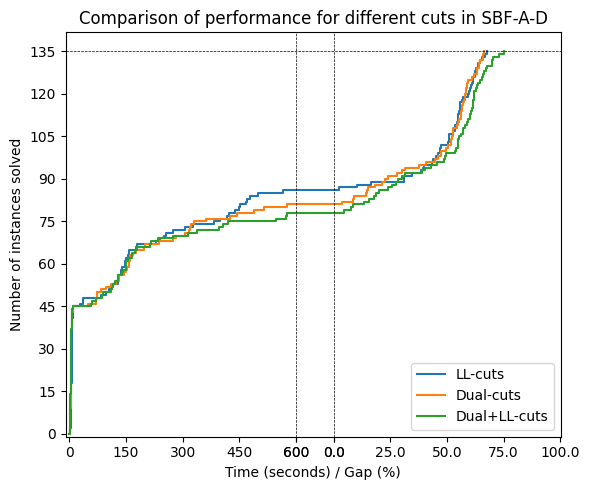

In [52]:
plot_single_time_gap(
    dfs,
    labels,
    title='Comparison of performance for different cuts in SBF-A-D',
    figsize=(6, 5)
)

In [53]:
summary = build_summary_table(dfs, labels)
print("\n" + "="*80)
print("Comparison between cut types for SBF-A-D")
print("="*80)

summary.style.hide(axis='index')


Comparison between cut types for SBF-A-D


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
LL-cuts,86,119.36,18.40,50.69,599.11
Dual-cuts,81,101.49,18.75,46.86,198.27
Dual+LL-cuts,78,93.99,20.90,49.49,480.24


## 4. General comparison between exact formulations

In [54]:
formulations = ['ABF', 'ABF-D', 'ABF-A-D',
                'SBF', 'SBF-D-enum', 'SBF-A-D-enum']
labels = ['ABF', 'ABF-D', 'ABF-A-D', 'SBF', 'SBF-D', 'SBF-A-D']
dfs = [df[df['Formulation'] == form].reset_index(drop=True) for form in formulations]

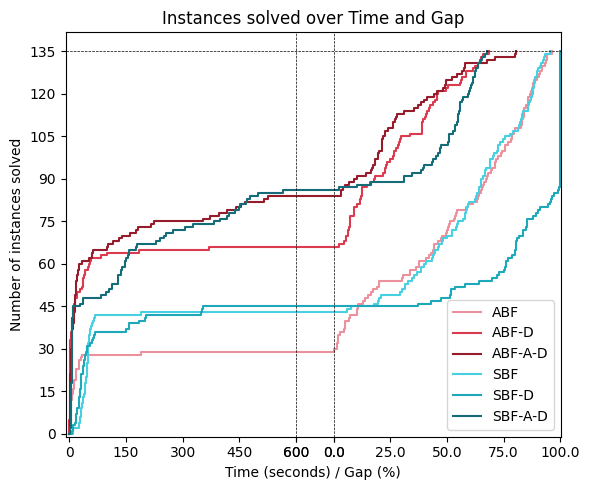

In [55]:
plot_single_time_gap(
    dfs,
    labels,
    title='Instances solved over Time and Gap',
    figsize=(6, 5)
)

In [56]:
summary = build_summary_table(dfs, labels)
print("\n" + "="*80)
print("Comparison between all formulations")
print("="*80)
summary.style.hide(axis='index')


Comparison between all formulations


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
ABF,29,17.42,42.55,54.18,-
ABF-D,66,21.87,15.57,30.47,12311.35
ABF-A-D,84,74.18,12.29,32.54,109.27
SBF,43,46.29,42.83,62.85,-
SBF-D,45,73.06,59.57,89.35,2232.52
SBF-A-D,86,119.36,18.40,50.69,599.11


## 5. Comparison per number of points

In [57]:
df_per_size = {}
for n in ns:
    df_per_size[n] = [df[(df['n'] == n) & (df['Formulation'] == form)].reset_index(drop=True) 
                      for form in formulations]

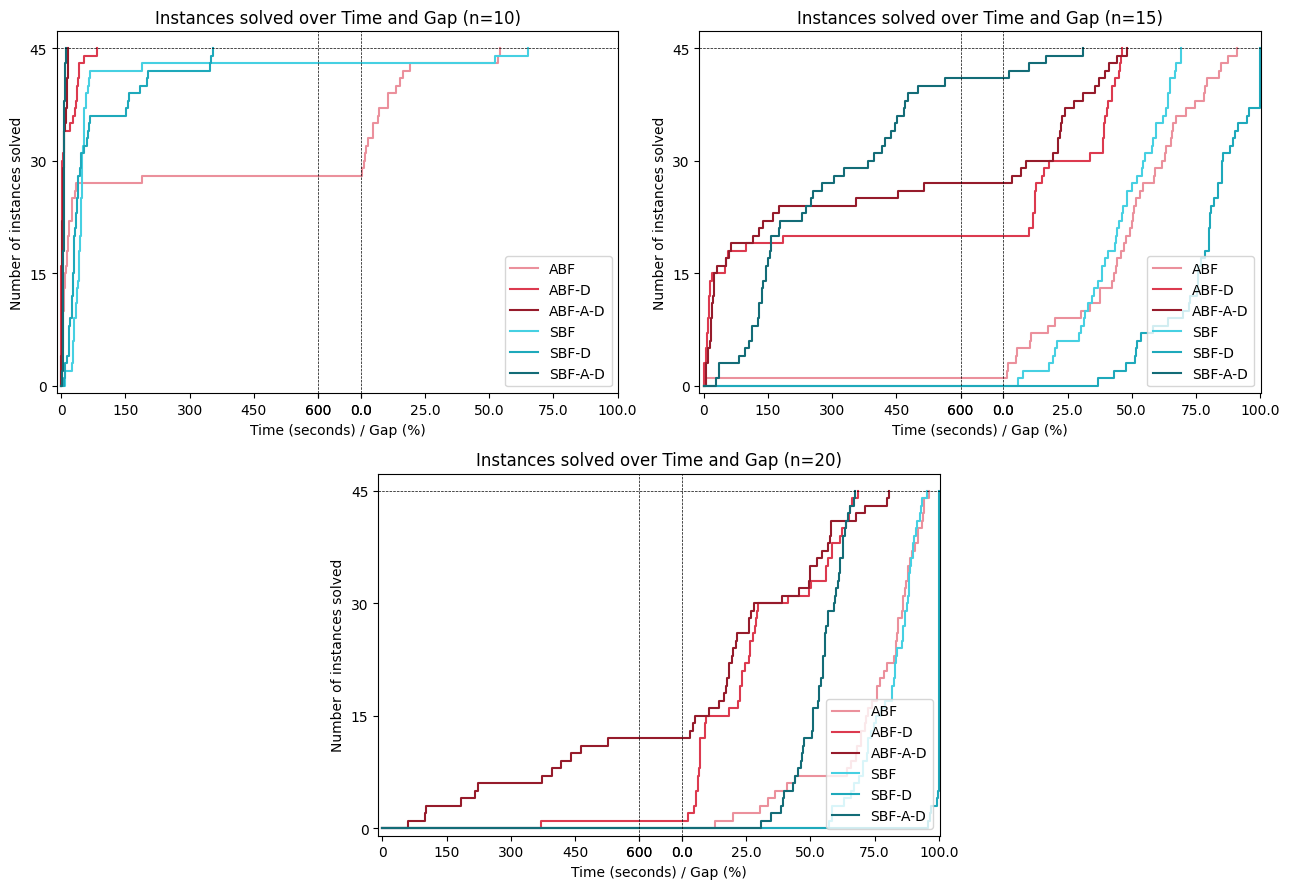

In [58]:
plot_triple_time_gap(
    [df_per_size[n] for n in ns],
    labels,
    colors=None,
    titles=[f'Instances solved over Time and Gap (n={n})' for n in ns],
    figsize=(13, 9)
)

In [59]:
# Print summary tables per size
for n in ns:
    summary_n = build_summary_table(df_per_size[n], labels)
    print("\n" + "="*80)
    print(f"Comparison between all formulations for n={n}")
    print("="*80)
    display(summary_n.style.hide(axis='index'))


Comparison between all formulations for n=10


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
ABF,28,17.88,5.00,13.21,-
ABF-D,45,11.00,0.00,-,1433.38
ABF-A-D,45,5.44,0.00,-,51.78
SBF,43,46.29,2.60,58.55,-
SBF-D,45,73.06,0.00,-,1656.38
SBF-A-D,45,5.79,0.00,-,201.96



Comparison between all formulations for n=15


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
ABF,1,4.35,48.57,49.68,-
ABF-D,20,28.89,16.72,30.09,15485.91
ABF-A-D,27,92.07,10.60,26.49,136.18
SBF,0,-,45.18,45.18,-
SBF-D,0,-,78.96,78.96,3030.91
SBF-A-D,41,244.02,1.33,14.99,1301.64



Comparison between all formulations for n=20


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
ABF,0,-,74.07,74.07,-
ABF-D,1,370.72,30.00,30.68,20014.76
ABF-A-D,12,291.72,26.28,35.84,139.87
SBF,0,-,80.71,80.71,-
SBF-D,0,-,99.73,99.73,2010.27
SBF-A-D,0,-,53.86,53.86,293.73


## 6. Comparison per mean radii

In [60]:
radii_categories = [small_r, med_r, big_r]
df_per_radii = {}
categories = ['r=0.25', 'r=0.5', 'r=1.0']
for cat, radii in zip(categories, radii_categories):
    df_per_radii[cat] = [df[df['r_max'].isin(radii) & (df['Formulation'] == form)].reset_index(drop=True) 
                         for form in formulations]

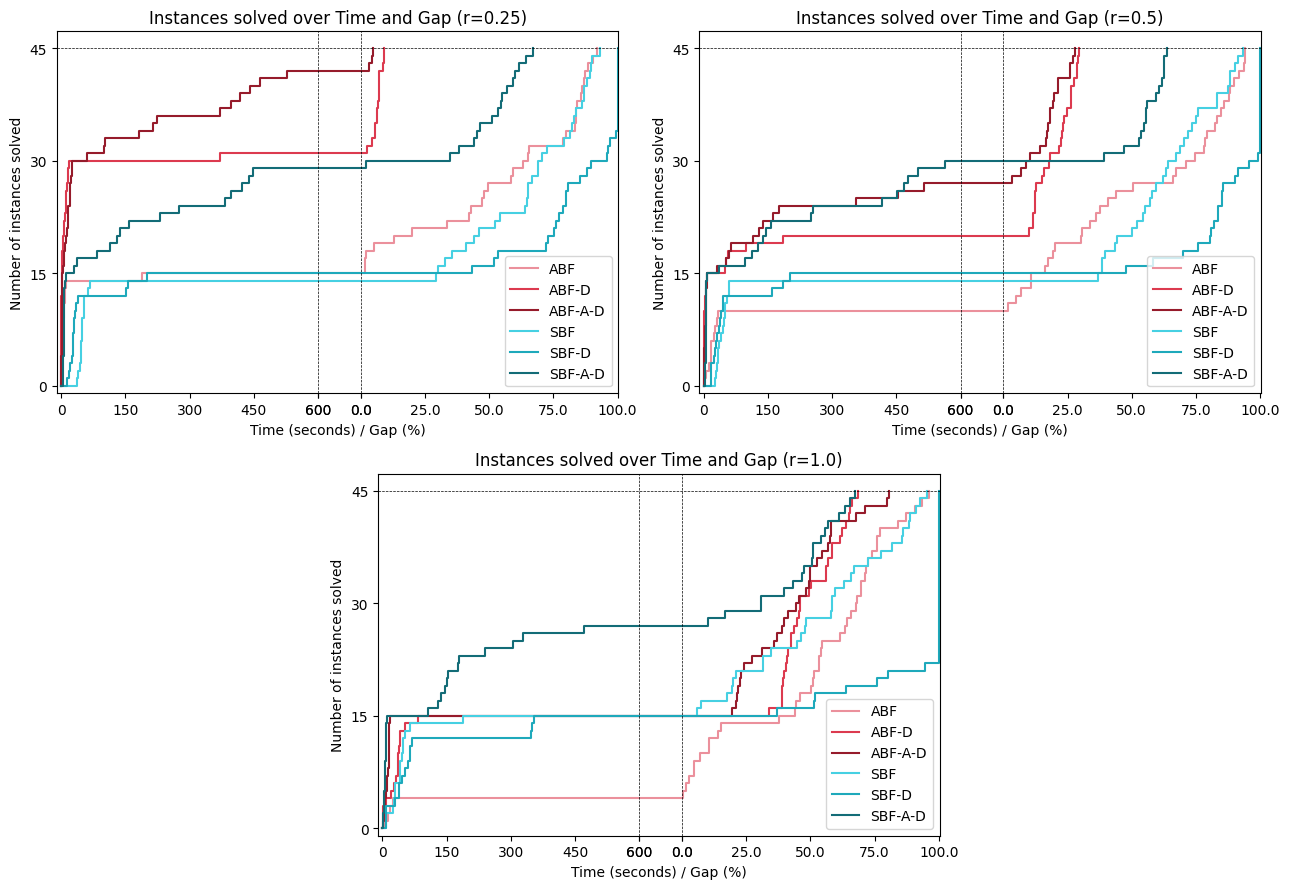

In [61]:
plot_triple_time_gap(
    [df_per_radii[cat] for cat in categories],
    labels,
    colors=None,
    titles=[f'Instances solved over Time and Gap ({cat})' for cat in categories],
    figsize=(13, 9)
)

In [62]:
# Print summary tables per radii category
for cat in categories:
    summary_r = build_summary_table(df_per_radii[cat], labels)
    print("\n" + "="*80)
    print(f"Comparison between all formulations for {cat}")
    print("="*80)
    display(summary_r.style.hide(axis='index'))


Comparison between all formulations for r=0.25


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
ABF,15,17.12,38.44,57.65,-
ABF-D,31,16.48,2.04,6.56,7572.98
ABF-A-D,42,89.35,0.28,4.15,77.29
SBF,14,49.58,46.46,67.44,-
SBF-D,15,55.75,57.61,86.42,2096.04
SBF-A-D,29,116.42,17.64,49.63,397.78



Comparison between all formulations for r=0.5


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
ABF,10,18.49,42.30,54.39,-
ABF-D,20,23.70,11.35,20.43,13114.40
ABF-A-D,27,85.53,7.11,17.77,85.60
SBF,14,42.33,45.01,65.33,-
SBF-D,15,60.75,59.85,89.78,2100.73
SBF-A-D,30,142.70,18.85,56.54,417.24



Comparison between all formulations for r=1.0


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
ABF,4,15.84,46.90,51.47,-
ABF-D,15,30.58,33.33,49.99,16246.67
ABF-A-D,15,11.28,29.49,44.24,164.93
SBF,15,46.90,37.03,55.55,-
SBF-D,15,102.68,61.23,91.85,2500.78
SBF-A-D,27,96.59,18.71,46.77,982.31


## 7. Comparison per radii variance

In [63]:
variance_categories = ['σ=0', 'σ=0.2', 'σ=0.5']
df_per_variance = {}
for var_cat, radii_set in zip(variance_categories, [no_var, med_var, high_var]):
    df_per_variance[var_cat] = [df[df['r_max'].isin(radii_set) & (df['Formulation'] == form)].reset_index(drop=True) 
                                for form in formulations]

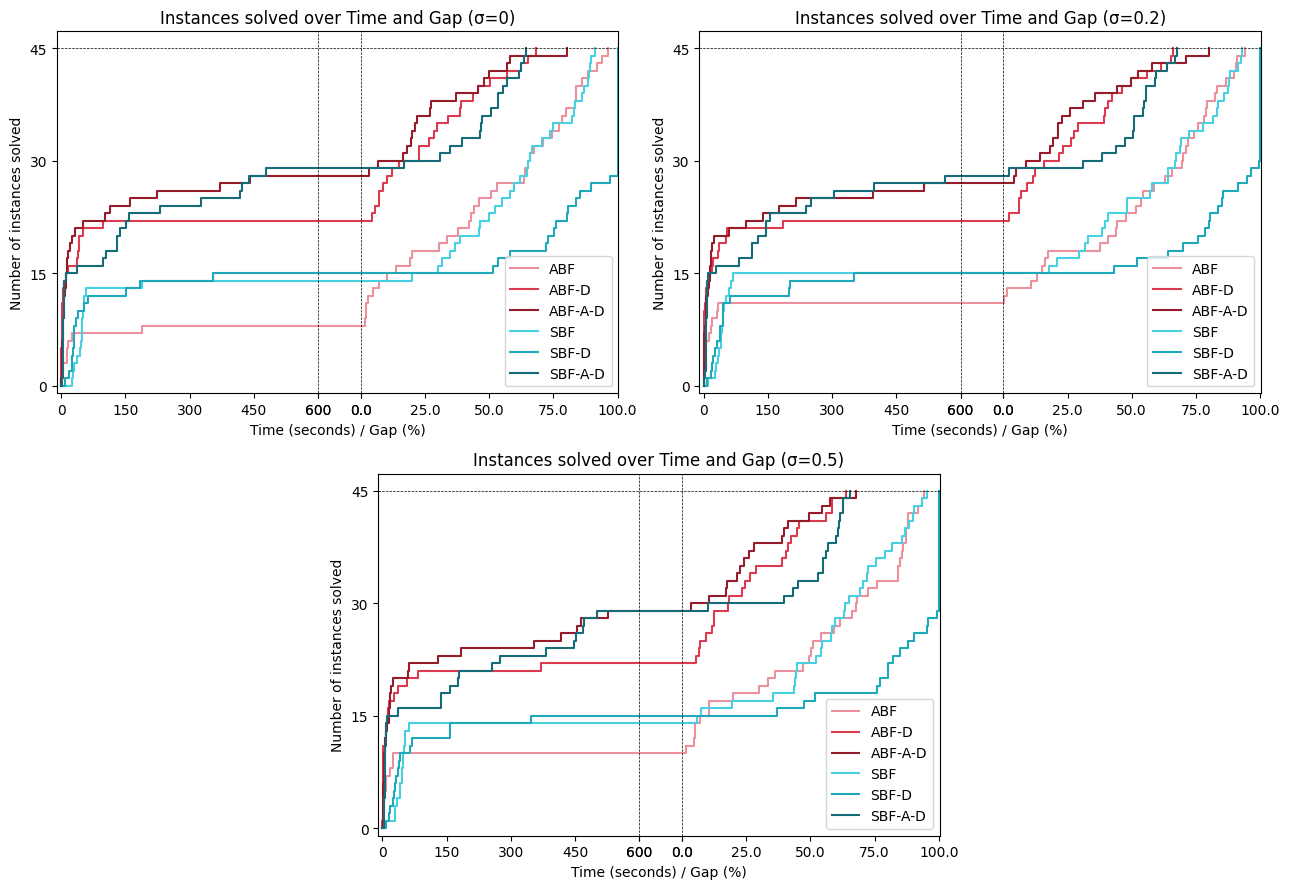

In [64]:
plot_triple_time_gap(
    [df_per_variance[cat] for cat in variance_categories],
    labels,
    colors=None,
    titles=[f'Instances solved over Time and Gap ({cat})' for cat in variance_categories],
    figsize=(13, 9)
)

In [65]:
# Print summary tables per variance
for cat in variance_categories:
    summary_var = build_summary_table(df_per_variance[cat], labels)
    print("\n" + "="*80)
    print(f"Comparison between all formulations for {cat}")
    print("="*80)
    display(summary_var.style.hide(axis='index'))


Comparison between all formulations for σ=0


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
ABF,8,33.11,41.75,50.78,-
ABF-D,22,16.33,15.65,30.62,12659.29
ABF-A-D,28,59.21,12.38,32.77,126.22
SBF,14,54.42,43.80,63.57,-
SBF-D,15,71.75,59.47,89.20,2215.04
SBF-A-D,29,115.13,17.42,49.00,703.02



Comparison between all formulations for σ=0.2


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
ABF,11,12.41,42.74,56.56,-
ABF-D,22,19.97,15.65,30.62,12380.58
ABF-A-D,27,65.16,12.97,32.41,106.31
SBF,15,42.51,41.97,62.95,-
SBF-D,15,76.54,59.55,89.33,2236.98
SBF-A-D,28,98.61,18.94,50.13,500.40



Comparison between all formulations for σ=0.5


Formulation,Opt,TimeOpt,Gap (%),Gap (NoOpt) (%),Cuts
ABF,10,10.37,43.15,55.48,-
ABF-D,22,29.32,15.42,30.16,11894.18
ABF-A-D,29,97.04,11.53,32.43,95.29
SBF,14,42.19,42.74,62.04,-
SBF-D,15,70.88,59.68,89.52,2245.53
SBF-A-D,29,143.63,18.83,52.97,593.91


## 8. Comparison of approximate formulations

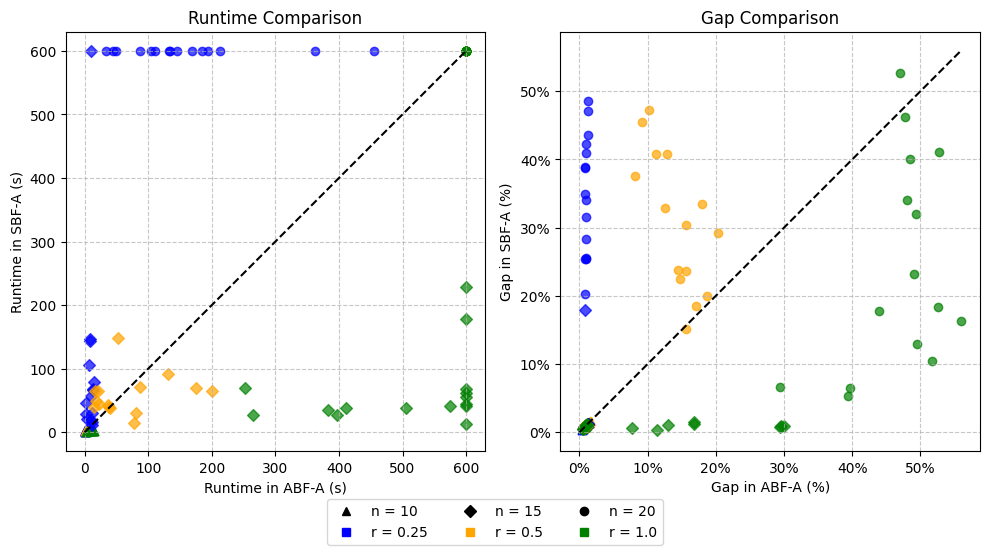

In [66]:
# Create figure and subplots (square axes)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax in axes:
    ax.set_aspect('equal', adjustable='box')

# --- Shared style info ---
n_values = [10, 15, 20]
markers = {10: '^', 15: 'D', 20: 'o'}
colors = {'small': 'blue', 'medium': 'orange', 'large': 'green'}

# Filter data for only the two formulations being compared
df_abf_a = df[df['Formulation'] == 'ABF-A']
df_sbf_a = df[df['Formulation'] == 'SBF-A']

# --- Plot 1: Runtime ---
ax = axes[0]

for n in n_values:
    subset1 = df_abf_a[df_abf_a['n'] == n]
    subset2 = df_sbf_a[df_sbf_a['n'] == n]

    for r_max in subset1['r_max'].unique():
        sub1 = subset1[subset1['r_max'] == r_max]
        sub2 = subset2[subset2['r_max'] == r_max]

        if r_max in small_r:
            c = colors['small']
        elif r_max in med_r:
            c = colors['medium']
        else:
            c = colors['large']

        ax.scatter(sub1['Time'], sub2['Time'],
                   marker=markers[n], color=c, alpha=0.7)

max_val = 600
ax.plot([0, max_val], [0, max_val], 'k--')
ax.set_xlabel('Runtime in ABF-A (s)')
ax.set_ylabel('Runtime in SBF-A (s)')
ax.set_title('Runtime Comparison')
ax.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Gap ---
ax = axes[1]

for n in n_values:
    subset1 = df_abf_a[df_abf_a['n'] == n]
    subset2 = df_sbf_a[df_sbf_a['n'] == n]

    for r_max in subset1['r_max'].unique():
        sub1 = subset1[subset1['r_max'] == r_max]
        sub2 = subset2[subset2['r_max'] == r_max]

        if r_max in small_r:
            c = colors['small']
        elif r_max in med_r:
            c = colors['medium']
        else:
            c = colors['large']

        ax.scatter(sub1['Gap'] * 100, sub2['Gap'] * 100,
                   marker=markers[n], color=c, alpha=0.7)

# Calculate max_val only from the data being plotted
max_val = max(df_abf_a['Gap'].max() * 100, df_sbf_a['Gap'].max() * 100)
ax.plot([0, max_val], [0, max_val], 'k--')
ax.set_xlabel('Gap in ABF-A (%)')
ax.set_ylabel('Gap in SBF-A (%)')
ax.set_title('Gap Comparison')
ax.xaxis.set_major_formatter(PercentFormatter())
ax.yaxis.set_major_formatter(PercentFormatter())
ax.grid(True, linestyle='--', alpha=0.7)

# --- Figure-wide legend ---
legend_elements = [
    Line2D([0], [0], marker='^', color='black', linestyle='None', label='n = 10'),
    Line2D([0], [0], marker='s', color='blue',   linestyle='None', label='r = 0.25'),
    Line2D([0], [0], marker='D', color='black', linestyle='None', label='n = 15'),
    Line2D([0], [0], marker='s', color='orange', linestyle='None', label='r = 0.5'),
    Line2D([0], [0], marker='o', color='black', linestyle='None', label='n = 20'),
    Line2D([0], [0], marker='s', color='green',  linestyle='None', label='r = 1.0')
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.1)
)

plt.tight_layout()
plt.show()